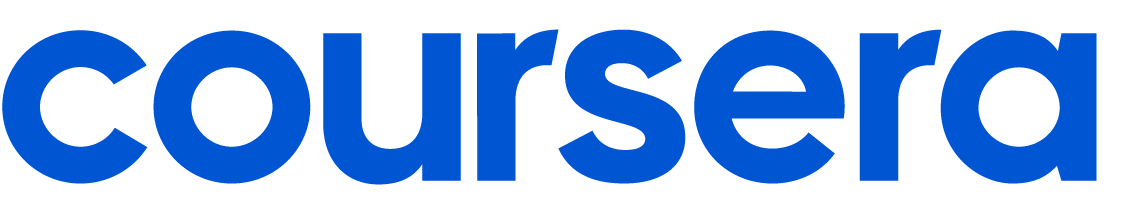

# Welcome to the Data Science Coding Challange!

Test your skills in a real-world coding challenge. Coding Challenges provide CS & DS Coding Competitions with Prizes and achievement badges!

CS & DS learners want to be challenged as a way to evaluate if they’re job ready. So, why not create fun challenges and give winners something truly valuable such as complimentary access to select Data Science courses, or the ability to receive an achievement badge on their Coursera Skills Profile - highlighting their performance to recruiters.

## Introduction

In this challenge, you'll get the opportunity to tackle one of the most industry-relevant maching learning problems with a unique dataset that will put your modeling skills to the test. Subscription services are leveraged by companies across many industries, from fitness to video streaming to retail. One of the primary objectives of companies with subscription services is to decrease churn and ensure that users are retained as subscribers. In order to do this efficiently and systematically, many companies employ machine learning to predict which users are at the highest risk of churn, so that proper interventions can be effectively deployed to the right audience.

In this challenge, we will be tackling the churn prediction problem on a very unique and interesting group of subscribers on a video streaming service! 

Imagine that you are a new data scientist at this video streaming company and you are tasked with building a model that can predict which existing subscribers will continue their subscriptions for another month. We have provided a dataset that is a sample of subscriptions that were initiated in 2021, all snapshotted at a particular date before the subscription was cancelled. Subscription cancellation can happen for a multitude of reasons, including:
* the customer completes all content they were interested in, and no longer need the subscription
* the customer finds themselves to be too busy and cancels their subscription until a later time
* the customer determines that the streaming service is not the best fit for them, so they cancel and look for something better suited

Regardless the reason, this video streaming company has a vested interest in understanding the likelihood of each individual customer to churn in their subscription so that resources can be allocated appropriately to support customers. In this challenge, you will use your machine learning toolkit to do just that!

## Understanding the Datasets

### Train vs. Test
In this competition, you’ll gain access to two datasets that are samples of past subscriptions of a video streaming platform that contain information about the customer, the customers streaming preferences, and their activity in the subscription thus far. One dataset is titled `train.csv` and the other is titled `test.csv`.

`train.csv` contains 70% of the overall sample (243,787 subscriptions to be exact) and importantly, will reveal whether or not the subscription was continued into the next month (the “ground truth”).

The `test.csv` dataset contains the exact same information about the remaining segment of the overall sample (104,480 subscriptions to be exact), but does not disclose the “ground truth” for each subscription. It’s your job to predict this outcome!

Using the patterns you find in the `train.csv` data, predict whether the subscriptions in `test.csv` will be continued for another month, or not.

### Dataset descriptions
Both `train.csv` and `test.csv` contain one row for each unique subscription. For each subscription, a single observation (`CustomerID`) is included during which the subscription was active. 

In addition to this identifier column, the `train.csv` dataset also contains the target label for the task, a binary column `Churn`.

Besides that column, both datasets have an identical set of features that can be used to train your model to make predictions. Below you can see descriptions of each feature. Familiarize yourself with them so that you can harness them most effectively for this machine learning task!

In [1]:
# pip install --upgrade pip

In [2]:
# !pip install tensorflow

In [3]:
# !pip install xgboost

In [4]:
# !pip install catboost

In [5]:
import pandas as pd
data_descriptions = pd.read_csv('data_descriptions.csv')
pd.set_option('display.max_colwidth', None)
data_descriptions

,Column_name,Column_type,Data_type,Description
0,AccountAge,Feature,integer,The age of the user's account in months.
1,MonthlyCharges,Feature,float,The amount charged to the user on a monthly basis.
2,TotalCharges,Feature,float,The total charges incurred by the user over the account's lifetime.
3,SubscriptionType,Feature,object,"The type of subscription chosen by the user (Basic, Standard, or Premium)."
4,PaymentMethod,Feature,string,The method of payment used by the user.
5,PaperlessBilling,Feature,string,Indicates whether the user has opted for paperless billing (Yes or No).
6,ContentType,Feature,string,"The type of content preferred by the user (Movies, TV Shows, or Both)."
7,MultiDeviceAccess,Feature,string,Indicates whether the user has access to the service on multiple devices (Yes or No).
8,DeviceRegistered,Feature,string,"The type of device registered by the user (TV, Mobile, Tablet, or Computer)."
9,ViewingHoursPerWeek,Feature,float,The number of hours the user spends watching content per week.


## How to Submit your Predictions to Coursera
Submission Format:

In this notebook you should follow the steps below to explore the data, train a model using the data in `train.csv`, and then score your model using the data in `test.csv`. Your final submission should be a dataframe (call it `prediction_df` with two columns and exactly 104,480 rows (plus a header row). The first column should be `CustomerID` so that we know which prediction belongs to which observation. The second column should be called `predicted_probability` and should be a numeric column representing the __likellihood that the subscription will churn__.

Your submission will show an error if you have extra columns (beyond `CustomerID` and `predicted_probability`) or extra rows. The order of the rows does not matter.

The naming convention of the dataframe and columns are critical for our autograding, so please make sure to use the exact naming conventions of `prediction_df` with column names `CustomerID` and `predicted_probability`!

To determine your final score, we will compare your `predicted_probability` predictions to the source of truth labels for the observations in `test.csv` and calculate the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html). We choose this metric because we not only want to be able to predict which subscriptions will be retained, but also want a well-calibrated likelihood score that can be used to target interventions and support most accurately.

## Import Python Modules

First, import the primary modules that will be used in this project. Remember as this is an open-ended project please feel free to make use of any of your favorite libraries that you feel may be useful for this challenge. For example some of the following popular packages may be useful:

- pandas
- numpy
- Scipy
- Scikit-learn
- keras
- maplotlib
- seaborn
- etc, etc

In [6]:
# Import required packages

# Data packages
import pandas as pd
import numpy as np

# Machine Learning / Classification packages
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

# Visualization Packages
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
# Import any other packages you may want to use
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit

from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

## Load the Data

Let's start by loading the dataset `train.csv` into a dataframe `train_df`, and `test.csv` into a dataframe `test_df` and display the shape of the dataframes.

In [8]:
train_df = pd.read_csv("train.csv")
print('train_df Shape:', train_df.shape)
train_df.head()

train_df Shape: (243787, 21)


,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [9]:
test_df = pd.read_csv("test.csv")
print('test_df Shape:', test_df.shape)
test_df.head()

test_df Shape: (104480, 20)


,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID
0,38,17.869374,679.036195,Premium,Mailed check,No,TV Shows,No,TV,29.126308,122.274031,42,Comedy,3.522724,2,Male,23,No,No,O1W6BHP6RM
1,77,9.912854,763.289768,Basic,Electronic check,Yes,TV Shows,No,TV,36.873729,57.093319,43,Action,2.021545,2,Female,22,Yes,No,LFR4X92X8H
2,5,15.019011,75.095057,Standard,Bank transfer,No,TV Shows,Yes,Computer,7.601729,140.414001,14,Sci-Fi,4.806126,2,Female,22,No,Yes,QM5GBIYODA
3,88,15.357406,1351.451692,Standard,Electronic check,No,Both,Yes,Tablet,35.586430,177.002419,14,Comedy,4.943900,0,Female,23,Yes,Yes,D9RXTK2K9F
4,91,12.406033,1128.949004,Standard,Credit card,Yes,TV Shows,Yes,Tablet,23.503651,70.308376,6,Drama,2.846880,6,Female,0,No,No,ENTCCHR1LR


## Explore, Clean, Validate, and Visualize the Data (optional)

Feel free to explore, clean, validate, and visualize the data however you see fit for this competition to help determine or optimize your predictive model. Please note - the final autograding will only be on the accuracy of the `prediction_df` predictions.

### Count and Percentage of NaNs in Numerical Features

In [10]:
# Select numeric columns
num_cols = train_df.select_dtypes(include=['float64', 'int64'])

# Compute number and percentage of NaNs
nan_count = num_cols.isnull().sum()
nan_percent = (nan_count / len(train_df)) * 100

# Combine into a summary table
missing_summary = pd.DataFrame({
    'Missing Values': nan_count,
    'Percent Missing': nan_percent.round(2)
})

# Filter only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]
missing_summary.sort_values(by='Percent Missing', ascending=False)

,Missing Values,Percent Missing


### Class Balance (Churned vs Not Churned)

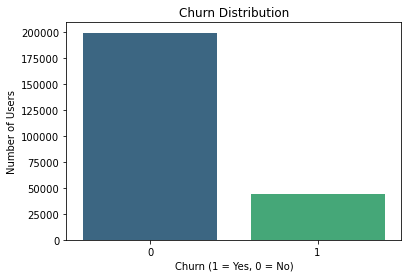

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=train_df, palette='viridis')
plt.title("Churn Distribution")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Number of Users")
plt.show()

### Distribution of Numerical Values

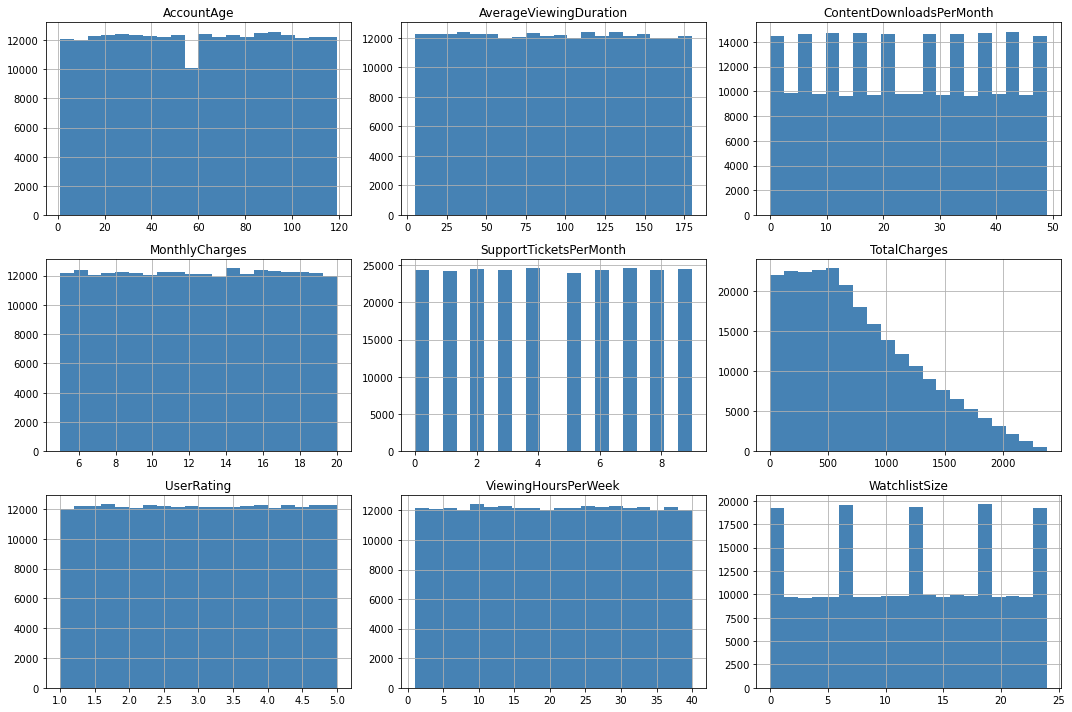

In [12]:
num_cols = ['AccountAge', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 
            'AverageViewingDuration', 'ContentDownloadsPerMonth', 'UserRating', 
            'SupportTicketsPerMonth', 'WatchlistSize']

train_df[num_cols].hist(bins=20, figsize=(15,10), color='steelblue')
# plt.suptitle("Distributions of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

### Churn vs Monthly Charges

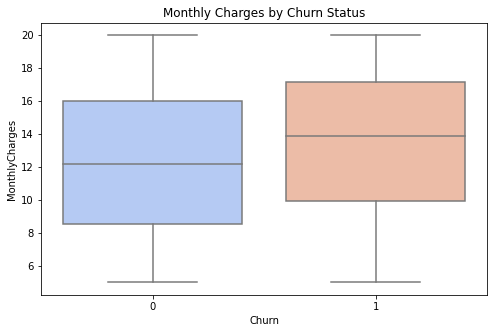

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=train_df, palette='coolwarm')
plt.title("Monthly Charges by Churn Status")
plt.show()

### Correlation Heatmap of Numerical Features

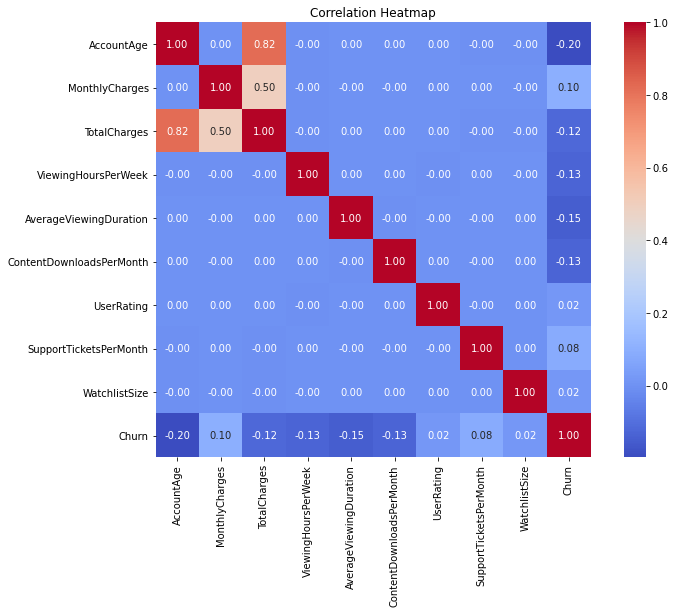

In [14]:
plt.figure(figsize=(12, 8))
corr = train_df[num_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

### Churn Rate by Subscription Types

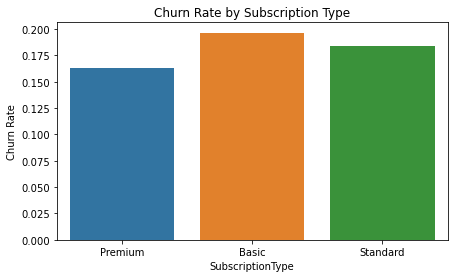

In [15]:
plt.figure(figsize=(7,4))
sns.barplot(x='SubscriptionType', y='Churn', data=train_df, estimator=lambda x: sum(x)/len(x), ci=None)
plt.title("Churn Rate by Subscription Type")
plt.ylabel("Churn Rate")
plt.show()

### Stacked Bar for Categorical Features

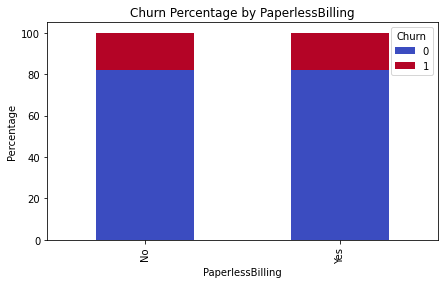

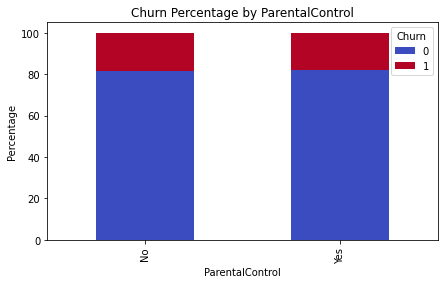

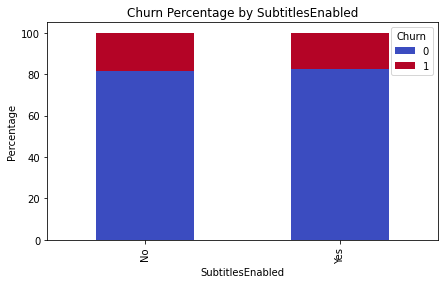

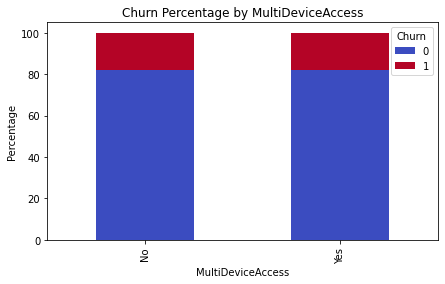

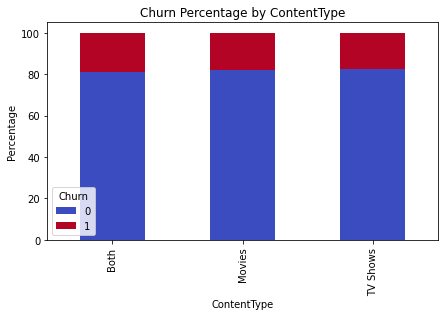

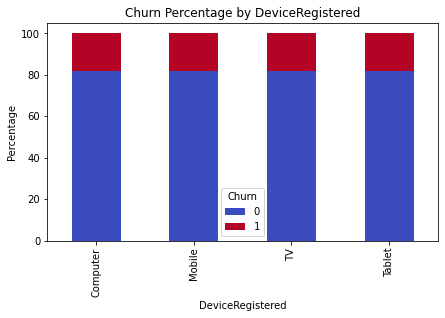

In [16]:
def stacked_bar(column):
    crosstab = pd.crosstab(train_df[column], train_df['Churn'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, figsize=(7,4), colormap='coolwarm')
    plt.title(f'Churn Percentage by {column}')
    plt.ylabel('Percentage')
    plt.legend(title='Churn')
    plt.show()

for col in ['PaperlessBilling', 'ParentalControl', 'SubtitlesEnabled', 
            'MultiDeviceAccess', 'ContentType', 'DeviceRegistered']:
    stacked_bar(col)

## Data Preprocessing

In this section, we first preprocess the categorical and numerical features accordingly based on the EDAs above. Then, we perform the train-test split for training purposes.

### Dropping Low-Variance and Irrelevant Features

In [17]:
# extract customer IDs in the test set for submission later
test_customer_IDs = test_df[['CustomerID']]

# drop CustomerID which is an irrelevant feature
train_df.drop('CustomerID', axis=1, inplace=True)
test_df.drop('CustomerID', axis=1, inplace=True)

In [18]:
# drop low-variance features
selector = VarianceThreshold(threshold=0.1)
train_df_numeric = train_df.select_dtypes(include=['float64', 'int64'])
selector.fit(train_df_numeric.drop('Churn', axis=1))
low_variance_cols = train_df_numeric.drop('Churn', axis=1).columns[~selector.get_support()]
print(list(low_variance_cols))

[]


In [19]:
train_df.drop(columns=low_variance_cols, inplace=True)
test_df.drop(columns=low_variance_cols, inplace=True)

### Binary and One-hot Encoding

In [20]:
# binary encoding
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['PaperlessBilling', 'MultiDeviceAccess', 'ParentalControl', 'SubtitlesEnabled', 'Gender']:
    train_df[col] = train_df[col].map(binary_map)
    test_df[col] = test_df[col].map(binary_map)

In [21]:
# one-hot encoding
one_hot_cols=['SubscriptionType', 'PaymentMethod', 'ContentType', 'DeviceRegistered', 'GenrePreference']
train_df = pd.get_dummies(train_df, columns=one_hot_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=one_hot_cols, drop_first=True)

### Feature Engineering

In [22]:
# Ratio features
train_df['SupportRate'] = train_df['SupportTicketsPerMonth'] / (train_df['AccountAge'] + 1)
train_df['ChargesPerMonth'] = train_df['TotalCharges'] / (train_df['AccountAge'] + 1)
test_df['SupportRate'] = test_df['SupportTicketsPerMonth'] / (test_df['AccountAge'] + 1)
test_df['ChargesPerMonth'] = test_df['TotalCharges'] / (test_df['AccountAge'] + 1)

# Interaction Features
train_df['CostEfficiency'] = train_df['ViewingHoursPerWeek'] / (train_df['MonthlyCharges'] + 1)
train_df['EngagementScore'] = train_df['ViewingHoursPerWeek'] * train_df['AccountAge']
test_df['CostEfficiency'] = test_df['ViewingHoursPerWeek'] / (test_df['MonthlyCharges'] + 1)
test_df['EngagementScore'] = test_df['ViewingHoursPerWeek'] * test_df['AccountAge']

# Combine boolean features into counts 
# (which may help save some training time as we combine mult features into one)
train_df['NumEnabledFeatures'] = (train_df['MultiDeviceAccess'] + train_df['ParentalControl'] 
                            + train_df['SubtitlesEnabled'] + train_df['PaperlessBilling'])
test_df['NumEnabledFeatures'] = (test_df['MultiDeviceAccess'] + test_df['ParentalControl'] 
                            + test_df['SubtitlesEnabled'] + test_df['PaperlessBilling'])

# Log transform for skewed features
train_df['LogTotalCharges'] = np.log1p(train_df['TotalCharges'])
test_df['LogTotalCharges'] = np.log1p(test_df['TotalCharges'])

# Drop columns related to the engineered features as they now become redundant
cols_to_drop = ['TotalCharges', 'SupportTicketsPerMonth', 'ViewingHoursPerWeek', 'MultiDeviceAccess', 
                'ParentalControl', 'SubtitlesEnabled', 'PaperlessBilling']
train_df.drop(cols_to_drop, axis=1, inplace=True)
test_df.drop(cols_to_drop, axis=1, inplace=True)

### Train-Test Split

In [23]:
X = train_df.drop('Churn', axis=1)
y = train_df['Churn']

In [24]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
# class weight calculation
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {0: 0.6106717016106811, 1: 2.7589333710567265}


In [26]:
# scale features
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [27]:
X_train_scaled.shape

(195029, 27)

In [28]:
X_test_scaled.shape

(48758, 27)

## Make predictions (required)

Remember you should create a dataframe named `prediction_df` with exactly 104,480 entries plus a header row attempting to predict the likelihood of churn for subscriptions in `test_df`. Your submission will throw an error if you have extra columns (beyond `CustomerID` and `predicted_probaility`) or extra rows.

The file should have exactly 2 columns:
`CustomerID` (sorted in any order)
`predicted_probability` (contains your numeric predicted probabilities between 0 and 1, e.g. from `estimator.predict_proba(X, y)[:, 1]`)

The naming convention of the dataframe and columns are critical for our autograding, so please make sure to use the exact naming conventions of `prediction_df` with column names `CustomerID` and `predicted_probability`!

### Define the XGBoost Model

In [29]:
# split the full training set to a training set and validation set for training XGB
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

# Initialize XGB
xgb_clf = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

In [30]:
# Train the model
xgb_clf.fit(X_train_xgb, y_train_xgb,
            eval_set=[(X_val_xgb, y_val_xgb)],
            early_stopping_rounds=5,
            verbose=False
           )

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=1000,
              n_jobs=0, num_parallel_tree=1, objective='binary:logistic',
              predictor='auto', random_state=42, reg_alpha=0, ...)

### Evaluate the Initial XGBoost Model on the Test Set

In [31]:
# Predict probabilities and labels
y_pred_probs_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_probs_xgb > 0.5).astype(int)

In [32]:
# Evaluate
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_probs_xgb))

[[26727 13194]
 [ 2717  6120]]
              precision    recall  f1-score   support

           0       0.91      0.67      0.77     39921
           1       0.32      0.69      0.43      8837

    accuracy                           0.67     48758
   macro avg       0.61      0.68      0.60     48758
weighted avg       0.80      0.67      0.71     48758

ROC AUC: 0.7498531408403385


### Extract Important Features

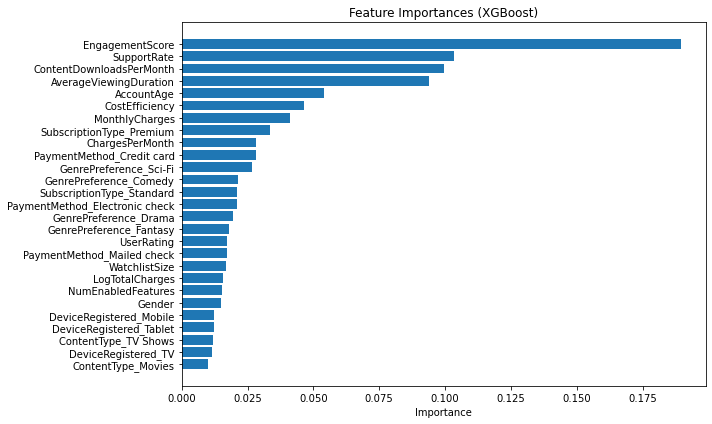

In [33]:
# Extract feature importances
importances = xgb_clf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the importances from highest to lowest
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:][::-1], importance_df['Importance'][:][::-1])
plt.xlabel("Importance")
plt.title("Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [34]:
# Drop features with very low importance (e.g., below threshold)
threshold = 0.01 # change if needed
low_importance = importance_df[importance_df['Importance'] < threshold]['Feature'].tolist()
print("Features to drop:", low_importance)

Features to drop: ['ContentType_Movies']


### Fine-Tune The XGB Model

In [35]:
# Try a few learning rates manually
learning_rates = [0.01, 0.02, 0.05, 0.1, 0.2]
best_auc = 0
best_lr = None
best_xgb_clf = None

# split the training set further to a smaller training set and validation set for fine tuning
X_train_xgb_ft, X_val_xgb_ft, y_train_xgb_ft, y_val_xgb_ft = train_test_split(
    X_train_xgb, y_train_xgb, test_size=0.1, stratify=y_train_xgb, random_state=42
)

# the parameters from the base model defined above
fixed_params = {
    'n_estimators': 1000,
    'max_depth': 6,
    'scale_pos_weight': scale_pos_weight,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'random_state': 42
}

for lr in learning_rates:
    print(f"Trying learning_rate = {lr}")
    
    model = XGBClassifier(**fixed_params, learning_rate=lr)
    model.fit(
        X_train_xgb_ft, y_train_xgb_ft,
        eval_set=[(X_val_xgb_ft, y_val_xgb_ft)],
        early_stopping_rounds=5,
        verbose=False
    )
    
    probs = model.predict_proba(X_val_xgb)[:, 1]
    auc = roc_auc_score(y_val_xgb, probs)
    print(f"AUC = {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        best_lr = lr
        best_xgb_clf = model

print("\nBest learning_rate:", best_lr)
print("Best validation AUC:", best_auc)

Trying learning_rate = 0.01
AUC = 0.7468
Trying learning_rate = 0.02
AUC = 0.7464
Trying learning_rate = 0.05
AUC = 0.7452
Trying learning_rate = 0.1
AUC = 0.7447
Trying learning_rate = 0.2
AUC = 0.7417

Best learning_rate: 0.01
Best validation AUC: 0.7467521942753967


### Evaluate the Fine-Tuned XGBoost Model on the Test Set

In [36]:
# Predict probabilities and labels
y_pred_probs_xgb = best_xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_probs_xgb > 0.5).astype(int)

In [37]:
# Evaluate
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_probs_xgb))

[[26822 13099]
 [ 2710  6127]]
              precision    recall  f1-score   support

           0       0.91      0.67      0.77     39921
           1       0.32      0.69      0.44      8837

    accuracy                           0.68     48758
   macro avg       0.61      0.68      0.60     48758
weighted avg       0.80      0.68      0.71     48758

ROC AUC: 0.7510364640981827


### Define the Random Forest Model

In [38]:
# Initialize Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight=class_weights,
    n_jobs=-1
)

# Train the model
rf_clf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                       class_weight={0: 0.6106717016106811,
                                     1: 2.7589333710567265},
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=200,
                       n_jobs=-1, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

### Evaluate The Initial RF Model on the Test Set

In [39]:
# Predict probabilities and labels using RF Classifier
y_pred_probs_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_pred_probs_rf > 0.5).astype(int)

In [40]:
# Evaluate
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs_rf))

[[39513   408]
 [ 8291   546]]
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     39921
           1       0.57      0.06      0.11      8837

    accuracy                           0.82     48758
   macro avg       0.70      0.53      0.51     48758
weighted avg       0.78      0.82      0.76     48758

ROC AUC Score: 0.7385490454204936


### Fine-Tune the RF Model

In [41]:
best_auc = 0
best_depth = None
best_rf_clf = None
depths = [3, 5, 10, 15, None]

# split the full training set to a training set and validation set for fine tuning RF
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

for depth in depths:
    print(f"Trying depth = {depth}")
    
    model = RandomForestClassifier(max_depth=depth, class_weight=class_weights, n_estimators=200, random_state=42)
    model.fit(X_train_rf, y_train_rf)
    probs = model.predict_proba(X_val_rf)[:, 1]
    auc = roc_auc_score(y_val_rf, probs)
    print(f"max_depth={depth}, AUC={auc:.4f}")
    
    if auc > best_auc:
        best_auc = auc
        best_depth = depth
        best_rf_clf = model
        
print("\nBest depth:", best_depth)
print("Best validation AUC:", best_auc)

Trying depth = 3
max_depth=3, AUC=0.7120
Trying depth = 5
max_depth=5, AUC=0.7275
Trying depth = 10
max_depth=10, AUC=0.7409
Trying depth = 15
max_depth=15, AUC=0.7402
Trying depth = None
max_depth=None, AUC=0.7340

Best depth: 10
Best validation AUC: 0.7409499160981086


### Evaluate The Fine-Tuned RF Model on the Test Set

In [42]:
# Predict probabilities and labels using RF Classifier
y_pred_probs_rf = best_rf_clf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_pred_probs_rf > 0.5).astype(int)

In [43]:
# Evaluate
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs_rf))

[[27969 11952]
 [ 3024  5813]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79     39921
           1       0.33      0.66      0.44      8837

    accuracy                           0.69     48758
   macro avg       0.61      0.68      0.61     48758
weighted avg       0.80      0.69      0.73     48758

ROC AUC Score: 0.7463444359416456


### Define The Neural Network Model

In [44]:
# define NN Model architecture
nn = Sequential()

# Input layer + Hidden 1
nn.add(Dense(128, input_shape=(X_train_scaled.shape[1],)))
nn.add(LeakyReLU(alpha=0.01))
nn.add(BatchNormalization())  # Normalize activation distribution
nn.add(Dropout(0.3))

# Hidden 2
nn.add(Dense(64))
nn.add(LeakyReLU(alpha=0.01))
nn.add(BatchNormalization())
nn.add(Dropout(0.3))

# Output
nn.add(Dense(1, activation='sigmoid'))

In [45]:
# compile the model
nn.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

nn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               3584      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 128)               0         
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 64)                0         
                                                        

In [46]:
# define early stopping
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True
)

# train the model
history = nn.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
5486/5486 [==============================] - 20s 3ms/step - loss: 0.6384 - accuracy: 0.6477 - auc: 0.7134 - val_loss: 0.6198 - val_accuracy: 0.6774 - val_auc: 0.7383
Epoch 2/50
5486/5486 [==============================] - 17s 3ms/step - loss: 0.6221 - accuracy: 0.6636 - auc: 0.7349 - val_loss: 0.6202 - val_accuracy: 0.6619 - val_auc: 0.7416
Epoch 3/50
5486/5486 [==============================] - 18s 3ms/step - loss: 0.6203 - accuracy: 0.6628 - auc: 0.7374 - val_loss: 0.6228 - val_accuracy: 0.6583 - val_auc: 0.7442
Epoch 4/50
5486/5486 [==============================] - 18s 3ms/step - loss: 0.6192 - accuracy: 0.6642 - auc: 0.7393 - val_loss: 0.6230 - val_accuracy: 0.6714 - val_auc: 0.7442
Epoch 5/50
5486/5486 [==============================] - 18s 3ms/step - loss: 0.6188 - accuracy: 0.6671 - auc: 0.7398 - val_loss: 0.6155 - val_accuracy: 0.6628 - val_auc: 0.7433
Epoch 6/50
5486/5486 [==============================] - 18s 3ms/step - loss: 0.6189 - accuracy: 0.6668 - auc: 0.739

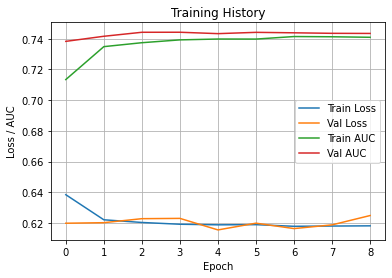

In [47]:
# Plot the training history of the neural network model
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss / AUC')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate The NN Model on the Test Set

In [48]:
# Predict probabilities and labels using NN
y_pred_probs_nn = nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_probs_nn > 0.5).astype(int)

1524/1524 [==============================] - 2s 1ms/step


In [49]:
# Evaluate
print(confusion_matrix(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs_nn))

[[26509 13412]
 [ 2633  6204]]
              precision    recall  f1-score   support

           0       0.91      0.66      0.77     39921
           1       0.32      0.70      0.44      8837

    accuracy                           0.67     48758
   macro avg       0.61      0.68      0.60     48758
weighted avg       0.80      0.67      0.71     48758

ROC AUC Score: 0.75234512826179


### Evaluate the Ensembled Model

In [50]:
from itertools import product

# We have predicted probabilities from 3 models above:
# y_pred_probs_nn  : from neural network
# y_pred_probs_rf  : from random forest
# y_pred_probs_xgb : from xgboost
# y_test    : true labels

# Normalize weights so they sum to 1
weight_options = np.arange(0.0, 1.1, 0.1)

best_auc = 0
best_weights = (0, 0, 0)

for w1, w2 in product(weight_options, repeat=2):
    w3 = 1.0 - w1 - w2
    if w3 < 0 or w3 > 1:
        continue  # invalid weight combination

    # Weighted average of probabilities
    probs_ensemble = w1 * y_pred_probs_nn + w2 * y_pred_probs_rf + w3 * y_pred_probs_xgb

    # Evaluate
    auc = roc_auc_score(y_test, probs_ensemble)

    if auc > best_auc:
        best_auc = auc
        best_weights = (w1, w2, w3)
        
final_probs_ensemble = best_weights[0] * y_pred_probs_nn + \
                        best_weights[1] * y_pred_probs_rf + \
                        best_weights[2] * y_pred_probs_xgb

print("Best Weights (NN, RF, XGB):", best_weights)

Best Weights (NN, RF, XGB): (0.6000000000000001, 0.0, 0.3999999999999999)


In [51]:
# Predict labels and calculate ROC AUC
y_pred_ensemble = (final_probs_ensemble > 0.5).astype(int)
auc = roc_auc_score(y_test, final_probs_ensemble)

In [52]:
# Evaluate
print(confusion_matrix(y_test, y_pred_ensemble))
print(classification_report(y_test, y_pred_ensemble))
print("ROC AUC:", auc)

[[26674 13247]
 [ 2640  6197]]
              precision    recall  f1-score   support

           0       0.91      0.67      0.77     39921
           1       0.32      0.70      0.44      8837

    accuracy                           0.67     48758
   macro avg       0.61      0.68      0.60     48758
weighted avg       0.80      0.67      0.71     48758

ROC AUC: 0.7531819314516546


### Extract The Predicted Probability for Submission

In [53]:
test_df_scaled = scalar.transform(test_df)
test_df_scaled.shape

(104480, 27)

In [54]:
predicted_probs_nn = nn.predict(test_df_scaled).flatten()
predicted_probs_rf = best_rf_clf.predict_proba(test_df)[:, 1]
predicted_probs_xgb = best_xgb_clf.predict_proba(test_df)[:, 1]

3265/3265 [==============================] - 4s 1ms/step


In [55]:
w1, w2, w3 = best_weights
predicted_probability = predicted_probs_nn * w1 + predicted_probs_rf * w2 + predicted_probs_xgb * w3
prediction_df = pd.DataFrame({'CustomerID': test_customer_IDs.values[:, 0],
                             'predicted_probability': predicted_probability})

In [56]:
prediction_df

,CustomerID,predicted_probability
0,O1W6BHP6RM,0.393197
1,LFR4X92X8H,0.209114
2,QM5GBIYODA,0.739947
3,D9RXTK2K9F,0.178451
4,ENTCCHR1LR,0.433259
...,...,...
104475,UTKREC613O,0.305323
104476,MDB4E477PS,0.372132
104477,IPDIA02ZE1,0.351698
104478,ITLFTPRJGV,0.593411


## Final Tests - **IMPORTANT** - the cells below must be run prior to submission

Below are some tests to ensure your submission is in the correct format for autograding. The autograding process accepts a csv `prediction_submission.csv` which we will generate from our `prediction_df` below. Please run the tests below an ensure no assertion errors are thrown.

In [57]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

# Writing to csv for autograding purposes
prediction_df.to_csv("prediction_submission.csv", index=False)
submission = pd.read_csv("prediction_submission.csv")

assert isinstance(submission, pd.DataFrame), 'You should have a dataframe named prediction_df.'

In [58]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

assert submission.columns[0] == 'CustomerID', 'The first column name should be CustomerID.'
assert submission.columns[1] == 'predicted_probability', 'The second column name should be predicted_probability.'

In [59]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

assert submission.shape[0] == 104480, 'The dataframe prediction_df should have 104480 rows.'

In [60]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

assert submission.shape[1] == 2, 'The dataframe prediction_df should have 2 columns.'

In [61]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

## This cell calculates the auc score and is hidden. Submit Assignment to see AUC score.

## SUBMIT YOUR WORK!

Once we are happy with our `prediction_df` and `prediction_submission.csv` we can now submit for autograding! Submit by using the blue **Submit Assignment** at the top of your notebook. Don't worry if your initial submission isn't perfect as you have multiple submission attempts and will obtain some feedback after each submission!